In [8]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('seaborn-v0_8-dark')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (16, 9),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd

import datetime
import pytz
NYC_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 

import warnings
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
)

import sys
sys.path.append("../../")

from RVUtils.plt_timeseries import make_secondary_axis_plot

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
from MDP.FixedRateBonds.WEBULL.WebullFintechFetcher import WebullFintechFetcher
from MDP.FixedRateBonds.WSJ.WSJFetcher import WSJFetcher

In [10]:
# start = CHI_tz.localize(datetime.datetime(2025, 10, 23, 7, 0))
# end = CHI_tz.localize(datetime.datetime(2025, 10, 24, 16, 00))

start = datetime.date(2025, 1, 1) 
end = datetime.date(2026, 3, 24)

wsjf = WSJFetcher()
ct_ts_df = wsjf.wsj_timeseries_api(
	wsj_ticker_keys=[
		# "TMUBMUSD01M",
		# "TMUBMUSD03M",
		# "TMUBMUSD04M",
		# "TMUBMUSD06M",
		"TMUBMUSD01Y",
		"TMUBMUSD02Y",
		"TMUBMUSD03Y",
		"TMUBMUSD05Y",
		"TMUBMUSD07Y",
		"TMUBMUSD10Y",
		"TMUBMUSD20Y",
		"TMUBMUSD30Y",
	],
	# start_date=start_date,
	# end_date=end_date,
	# intraday_timestamp=True,
	append_most_recent_last=True,
	one_df=True,
	show_tqdm=True,
)
ct_ts_df.columns = [
	# "1M",
	# "3M",
	# "4M",
	# "6M",
	"CT1",
	"CT2",
	"CT3",
	"CT5",
	"CT7",
	"CT10",
	"CT20",
	"CT30",
]

def merge_rows_same_date(df: pd.DataFrame) -> pd.DataFrame:
	if not isinstance(df.index, pd.DatetimeIndex):
		raise ValueError("The DataFrame index must be a DatetimeIndex.")

	grouped = df.groupby(df.index.normalize())

	merged_rows = []
	for _, group_df in grouped:
		group_df = group_df.sort_index()
		new_index = group_df.index.max()
		merged = group_df.iloc[-1].copy()
		for _, row in group_df.iloc[-2::-1].iterrows():
			merged = row.combine_first(merged)
		merged.name = new_index
		merged_rows.append(merged)

	merged_df = pd.DataFrame(merged_rows)
	merged_df.sort_index(inplace=True)
	return merged_df

ct_ts_df = merge_rows_same_date(ct_ts_df)

ct_ts_df: pd.DataFrame = ct_ts_df[
	(ct_ts_df.index.date >= start.date() if type(start) == datetime.datetime else ct_ts_df.index.date >= start)
	& (ct_ts_df.index.date <= end.date() if type(end) == datetime.datetime else ct_ts_df.index.date <= end)
]
ct_ts_df
ct_ts_df["2s10s"] = (ct_ts_df["CT10"] - ct_ts_df["CT2"]) * 100
ct_ts_df["2s7s"] = (ct_ts_df["CT7"] - ct_ts_df["CT2"]) * 100
ct_ts_df["5s30s"] = (ct_ts_df["CT30"] - ct_ts_df["CT5"]) * 100
ct_ts_df["2s5s10s"] = ((ct_ts_df["CT5"] - ct_ts_df["CT2"]) - (ct_ts_df["CT10"] - ct_ts_df["CT5"])) * 100 

ustf_df = WebullFintechFetcher(debug_verbose=True).eod_by_tickers(["TU", "FV", "TY", "UXY", "UB"], start=start, end=end, one_df=True)
ustf_df["TUL"] = 5 * ustf_df["TU"] - ustf_df["UXY"] 
ustf_df["TUT"] = 3 * ustf_df["TU"] - ustf_df["TY"]


ustf_df["TUF"] = 12 * ustf_df["TU"] - 10 * ustf_df["FV"]
ustf_df["FIX"] = 10 * ustf_df["FV"] - 5 * ustf_df["UXY"] 
ustf_df["TUF-FIX"] = ustf_df["TUF"] - ustf_df["FIX"] 

FETCHING FUTURES EOD...: 100%|██████████| 5/5 [00:00<00:00, 43.41it/s]


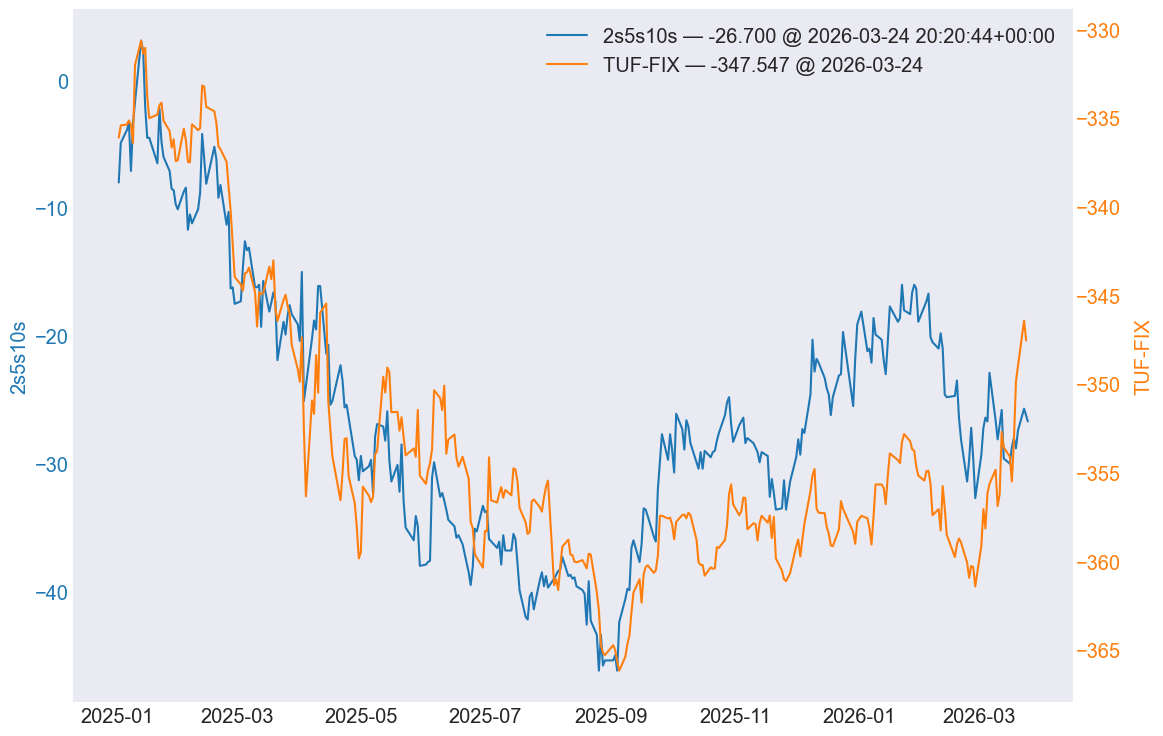

In [11]:
plot, fig, _, _, legend = make_secondary_axis_plot()
plot(ct_ts_df["2s5s10s"], which="left")
plot(ustf_df["TUF-FIX"], which="right")
# plot(ct_ts_df["2s7s"], which="left")
# plot(ustf_df["TUT"], which="right")
legend(valfmt="{:.3f}", show_date=True)

In [18]:
from MDP.FixedRateBonds.WEBULL.WebullFintechFetcher import WebullFintechFetcher

codes = ["G6", "H6", "J6", "K6"]
tickers = [f"SER{c}" for c in codes] + [f"FF{c}" for c in codes]

# start = datetime.date(2025, 10, 1) 
# end = datetime.date(2026, 3, 24)
# df = WebullFintechFetcher(debug_verbose=True).eod_by_tickers(tickers, start=start, end=end)

start = CHI_tz.localize(datetime.datetime(2026, 2, 27, 0, 0))
end = CHI_tz.localize(datetime.datetime(2026, 3, 24, 16, 59))
df = WebullFintechFetcher(debug_verbose=True).intraday_by_tickers(tickers, start=start, end=end)

plot, fig, _, _, legend = make_secondary_axis_plot(engine="plotly")
plot(100 - df["SERK6"], which="left")
legend(valfmt="{:.3f}", show_date=True)

FETCHING FUTURES INTRADAY...: 100%|██████████| 8/8 [00:01<00:00,  7.23it/s]
